<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
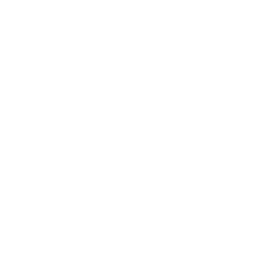
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Παρεμβολή Εγγραφών Ασθενών από Τριμηνιαία σε Μηνιαία Συχνότητα</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Φαρμακευτικός Τομέας / Κλινικές Λειτουργίες &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Αυτό το πρακτικό παράδειγμα μετατρέπει τα **τριμηνιαία** πλήθη εγγραφών σε κλινική δοκιμή σε **μηνιαίες** εκτιμήσεις με τη διαδικασία PROC EXPAND, ώστε ο σχεδιασμός πόρων ανά κέντρο να μπορεί να γίνεται σε μηνιαία βάση. Η συνθετική δοκιμή καλύπτει **τέσσερα ερευνητικά κέντρα** σε δύο περιοχές (Βόρεια Αμερική και Ευρώπη) σε διάστημα **οκτώ τριμήνων** (Q1 2024 έως Q4 2025), δίνοντας **32 τριμηνιαίες παρατηρήσεις**. Η PROC EXPAND παρεμβάλλει τη σειρά κάθε κέντρου από τριμηνιαία σε μηνιαία συχνότητα, μετατρέποντας αυτές τις 32 τριμηνιαίες γραμμές σε **96 μηνιαίες γραμμές**. Τα πλήθη εγγραφών παρεμβάλλονται με `METHOD=JOIN` (κατά τμήματα γραμμική, που διατηρεί κάθε εκτίμηση μη αρνητική) και το τρέχον αθροιστικό σύνολο παρεμβάλλεται με `METHOD=SPLINE`. Η παρεμβαλλόμενη μηνιαία σειρά διέρχεται ακριβώς από τα αρχικά τριμηνιαία σημεία αναφοράς, οπότε η μετατροπή προσθέτει ενδοτριμηνιαία λεπτομέρεια χωρίς να αλλοιώνει τα τριμηνιαία μεγέθη που η μελέτη έχει ήδη αναφέρει.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Τριμηνιαία πλήθη εγγραφών ανά κέντρο (4 κέντρα x 8 τρίμηνα) | 32 |
| WORK.SITE_MASTER | Στοιχεία αναφοράς κέντρου: όνομα, χώρα, περιοχή, PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Δημιουργία τριμηνιαίων πληθών εγγραφών ανά κέντρο.
   4 κέντρα x 8 τρίμηνα (Q1-2024 έως Q4-2025) = 32 γραμμές.
   Μια καμπύλη ανάπτυξης (αργή εκκίνηση, σταθεροποίηση) μαζί με έναν
   ήπιο εποχικό όρο και μικρό θόρυβο παράγει ένα ρεαλιστικό σχήμα
   εγγραφών.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.enrollment_qtr;
    CALL streaminit(42);
    ΜΟΡΦΗ quarter_date yyq7.;
    LENGTH region $40;
    ARRAY capacity[4] _temporary_ (12 9 14 8);
    ΕΠΑΝΑΛΗΨΗ site_num = 1 ΕΩΣ 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, 'ΒΟΡΕΙΑ_ΑΜΕΡΙΚΗ', 'ΕΥΡΩΠΗ');
        base_rate = capacity[site_num];
        ΕΠΑΝΑΛΗΨΗ qtr_seq = 0 ΕΩΣ 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
ΕΚΤΕΛΕΣΗ;

/* Τρέχον αθροιστικό σύνολο εγγραφών εντός κάθε κέντρου */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.enrollment_qtr;
    ΚΑΤΑ site_id quarter_date;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.enrollment_qtr;
    ΟΡΙΣΜΟΣ work.enrollment_qtr;
    ΚΑΤΑ site_id;
    RETAIN cum_enrolled 0;
    ΕΑΝ first.site_id ΤΟΤΕ cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    ΑΦΑΙΡΕΣΗ cum_enrolled;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Πίνακας αναφοράς κέντρου (4 κέντρα, 2 περιοχές)
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.site_master;
    LENGTH site_id $8 site_name $80 region $40 country $40 pi_name $40;
    ARRAY names[4] $80 _temporary_ (
        'Γενικό Νοσοκομείο Μητρόπολης'   'Πανεπιστημιακό Ιατρικό Κέντρο'
        'Βασιλικό Νοσηλευτήριο Λονδίνου'   'Πανεπιστημιακή Κλινική Charite Βερολίνου'
    );
    ARRAY countries[4] $40 _temporary_ ('ΗΠΑ' 'ΗΠΑ' 'Ηνωμένο Βασίλειο' 'Γερμανία');
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 4;
        site_id   = cat('SITE-', PUT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'ΒΟΡΕΙΑ_ΑΜΕΡΙΚΗ', 'ΕΥΡΩΠΗ');
        pi_name   = cat('Δρ. Ερευνητής-', PUT(i, z2.));
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ i;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Βασική σύνοψη τριμηνιαίων εγγραφών ανά περιοχή
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.enrollment_qtr n sum mean MAX;
    ΚΛΑΣΗ region;
    ΜΕΤΑΒΛΗΤΗ enrolled_count cumulative_enrolled;
    ΕΤΙΚΕΤΑ region="Περιοχή" enrolled_count="Αριθμός Εγγραφών"
          cumulative_enrolled="Αθροιστικός Αριθμός Εγγραφών";
    ΕΞΟΔΟΣ out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.qtr_baseline noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ region="Περιοχή" total_enrolled="Σύνολο Εγγραφών"
          avg_per_quarter="Μέσος Όρος ανά Τρίμηνο"
          max_cumulative="Μέγιστο Αθροιστικό";
    TITLE "Βασικές Τριμηνιαίες Εγγραφές ανά Περιοχή";
ΕΚΤΕΛΕΣΗ;


                                                  The MEANS Procedure

                           Analysis Variable : enrolled_count Αριθμός Εγγραφών

        Περιοχή                              N Obs            Sum           Mean        Maximum
        ---------------------------------------------------------------------------------------
        ΒΟΡΕΙΑ_ΑΜΕΡΙΚΗ                          16    115.0000000      7.1875000     10.0000000
        ΕΥΡΩΠΗ                                  16    120.0000000      7.5000000     13.0000000
        ---------------------------------------------------------------------------------------

             Analysis Variable : cumulative_enrolled Αθροιστικός Αριθμός Εγγραφών

        Περιοχή                              N Obs            Sum           Mean        Maximum
        ---------------------------------------------------------------------------------------
        ΒΟΡΕΙΑ_ΑΜΕΡΙΚΗ                          16    474.0000000     29.6250000     63.00000


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Η βασική εικόνα επιβεβαιώνει έναν ισορροπημένο σχεδιασμό: κάθε περιοχή συνεισφέρει **16 τριμηνιαίες παρατηρήσεις**. Η Βόρεια Αμερική εγγράφει συνολικά **115 συμμετέχοντες** (μέσος όρος **7.19** ανά κέντρο-τρίμηνο) και η Ευρώπη **120** (μέσος όρος **7.50**). Το μεγαλύτερο αθροιστικό πλήθος που επιτεύχθηκε στα οκτώ τρίμηνα είναι **81** συμμετέχοντες (το SITE-003 της Ευρώπης) έναντι **63** στη Βόρεια Αμερική.


---

                                        Βασικές Τριμηνιαίες Εγγραφές ανά Περιοχή                                        




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


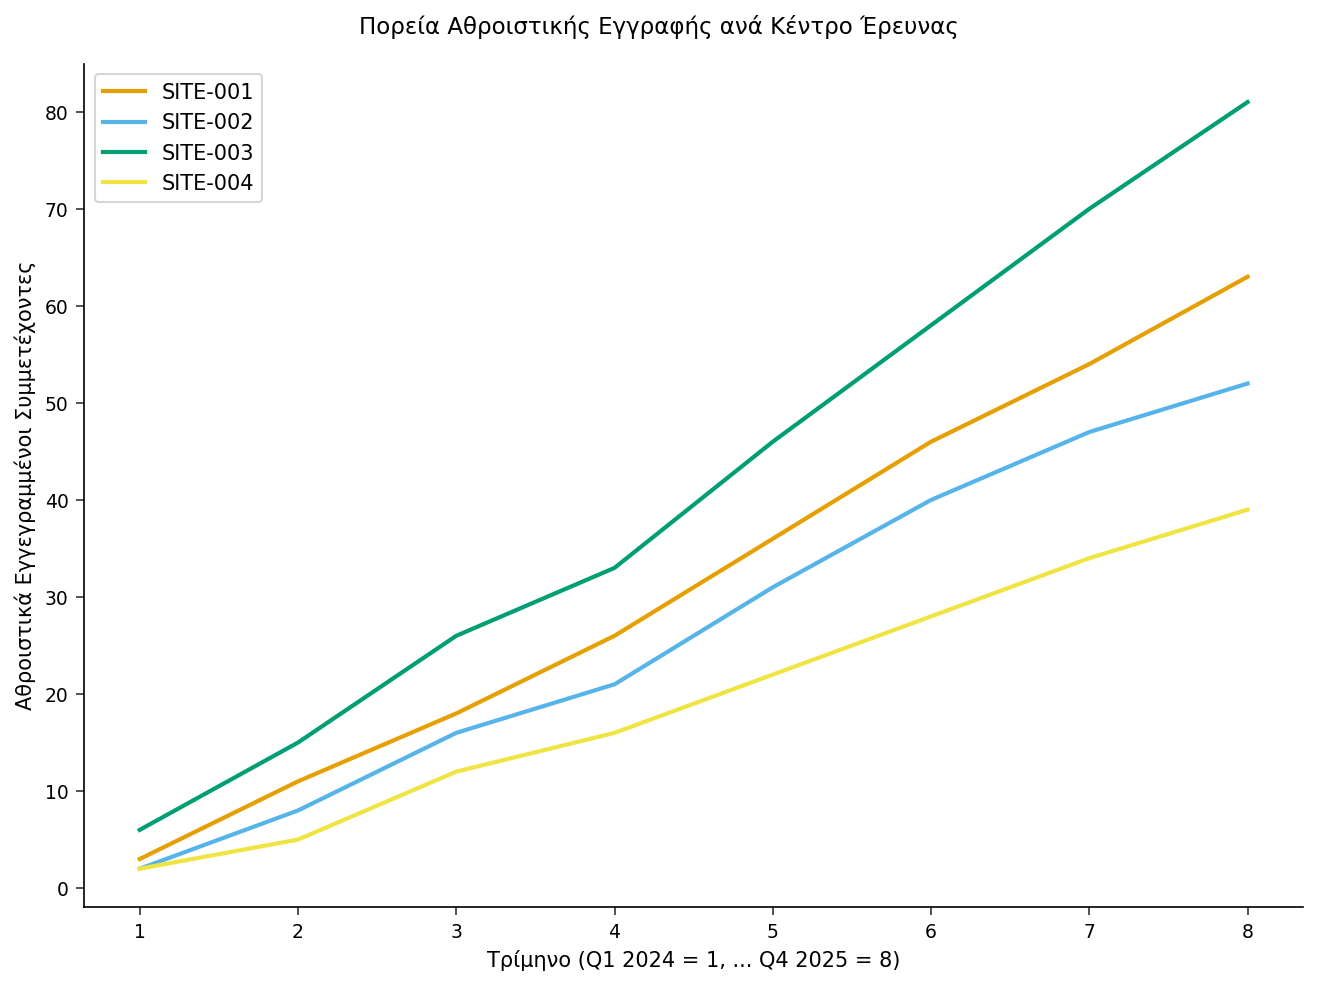

In [4]:
/* --------------------------------------------------------
   Πορεία αθροιστικής τριμηνιαίας εγγραφής ανά κέντρο.
   Σχεδιάζεται σε σχέση με έναν δείκτη τριμήνου (1..8) για έναν
   καθαρό άξονα.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.traj;
    ΟΡΙΣΜΟΣ work.enrollment_qtr;
    ΚΑΤΑ site_id;
    RETAIN quarter_index 0;
    ΕΑΝ first.site_id ΤΟΤΕ quarter_index = 0;
    quarter_index + 1;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS ΕΤΙΚΕΤΑ="Τρίμηνο (Q1 2024 = 1, ... Q4 2025 = 8)"
        integer VALUES=(1 ΕΩΣ 8 ΚΑΤΑ 1);
    YAXIS ΕΤΙΚΕΤΑ="Αθροιστικά Εγγεγραμμένοι Συμμετέχοντες";
    TITLE "Πορεία Αθροιστικής Εγγραφής ανά Κέντρο Έρευνας";
ΕΚΤΕΛΕΣΗ;


---

In [5]:
/* --------------------------------------------------------
   Η PROC EXPAND απαιτεί η μεταβλητή ID να είναι ταξινομημένη
   εντός κάθε ομάδας BY, οπότε ταξινομούμε ανά κέντρο και μετά
   τρίμηνο πριν τη μετατροπή.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.enrollment_qtr;
    ΚΑΤΑ site_id quarter_date;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Μετατροπή τριμηνιαίων εγγραφών σε μηνιαίες εκτιμήσεις.

   FROM=QTR / TO=MONTH στη δήλωση PROC ορίζουν τις συχνότητες
   εισόδου και εξόδου· η PROC EXPAND παρεμβάλλει κάθε ομάδα BY
   (κέντρο) ανεξάρτητα κατά μήκος της ημερομηνίας ID.

   enrolled_count      -> METHOD=JOIN   (κατά τμήματα γραμμική·
                          η τιμή ροής παραμένει μη αρνητική
                          μεταξύ σημείων αναφοράς)
   cumulative_enrolled -> METHOD=SPLINE (ομαλή μονότονη καμπύλη)
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPAND ΔΕΔΟΜΕΝΑ=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr TO=month;
    ΚΑΤΑ site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=end     METHOD=SPLINE;
ΕΚΤΕΛΕΣΗ;


                                        Βασικές Τριμηνιαίες Εγγραφές ανά Περιοχή                                        




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                        Βασικές Τριμηνιαίες Εγγραφές ανά Περιοχή                                        




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


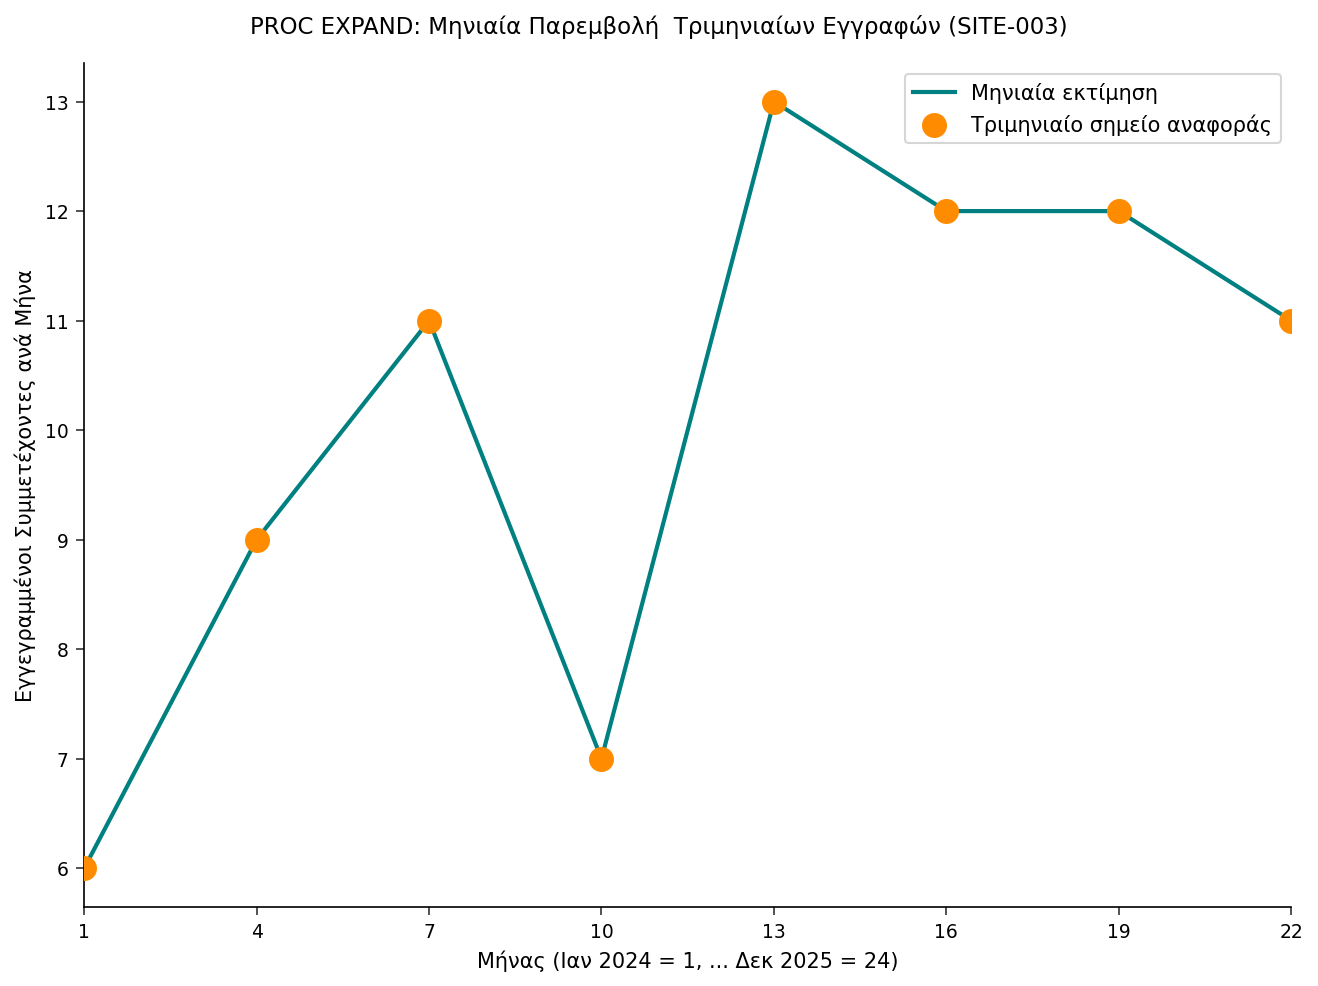

In [7]:
/* --------------------------------------------------------
   Η μεταβλητή ID φέρει πλέον μηνιαίες ημερομηνίες. Επαναμορφοποιούμε
   και προσθέτουμε έναν δείκτη μήνα εντός κέντρου (1..24) για γράφημα.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.enrollment_monthly;
    ΟΡΙΣΜΟΣ work.enrollment_monthly;
    ΚΑΤΑ site_id;
    ΜΟΡΦΗ month_date monyy7.;
    month_date = quarter_date;
    RETAIN month_index 0;
    ΕΑΝ first.site_id ΤΟΤΕ month_index = 0;
    month_index + 1;
    /* επισήμανση των μηνών-άγκυρας τριμήνου (1, 4, 7, ...) */
    ΕΑΝ mod(month_index - 1, 3) = 0 ΤΟΤΕ anchor = enrolled_count;
    ΑΛΛΙΩΣ anchor = .;
ΕΚΤΕΛΕΣΗ;

/* Εμφάνιση της μετατροπής για ένα κέντρο: η παρεμβαλλόμενη μηνιαία
   γραμμή διέρχεται από τα αρχικά τριμηνιαία σημεία αναφοράς. */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.enrollment_monthly;
    ΟΠΟΥ site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel="Μηνιαία εκτίμηση";
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel="Τριμηνιαίο σημείο αναφοράς";
    XAXIS ΕΤΙΚΕΤΑ="Μήνας (Ιαν 2024 = 1, ... Δεκ 2025 = 24)"
        integer VALUES=(1 ΕΩΣ 24 ΚΑΤΑ 3);
    YAXIS ΕΤΙΚΕΤΑ="Εγγεγραμμένοι Συμμετέχοντες ανά Μήνα";
    TITLE 'PROC EXPAND: Μηνιαία Παρεμβολή '
        'Τριμηνιαίων Εγγραφών (SITE-003)';
ΕΚΤΕΛΕΣΗ;


In [8]:
/* --------------------------------------------------------
   Σύνδεση των μηνιαίων εκτιμήσεων με τα μεταδεδομένα κέντρου,
   έπειτα σύνοψη της μηνιαίας εγγραφής ανά περιοχή.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    ΕΠΙΛΟΓΗ e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER ΚΑΤΑ s.region, e.site_id, e.month_date;
QUIT;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.enrollment_monthly_region n sum mean;
    ΚΛΑΣΗ region;
    ΜΕΤΑΒΛΗΤΗ monthly_estimate cumulative_estimate;
    ΕΤΙΚΕΤΑ region="Περιοχή" monthly_estimate="Μηνιαία Εκτίμηση"
          cumulative_estimate="Αθροιστική Εκτίμηση";
    ΕΞΟΔΟΣ out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.region_monthly_summary noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ region="Περιοχή" total_monthly_enrolled="Σύνολο Μηνιαίων Εγγραφών"
          avg_monthly_rate="Μέσος Μηνιαίος Ρυθμός";
    TITLE "Μηνιαίες Εκτιμήσεις ανά Περιοχή";
ΕΚΤΕΛΕΣΗ;


                                        Βασικές Τριμηνιαίες Εγγραφές ανά Περιοχή                                        

                                        Βασικές Τριμηνιαίες Εγγραφές ανά Περιοχή                                        

                                                  The MEANS Procedure

                          Analysis Variable : monthly_estimate Μηνιαία Εκτίμηση

        Περιοχή                              N Obs            Sum           Mean
        ------------------------------------------------------------------------
        ΒΟΡΕΙΑ_ΑΜΕΡΙΚΗ                          44    326.0000000      7.4090909
        ΕΥΡΩΠΗ                                  44    336.0000000      7.6363636
        ------------------------------------------------------------------------

                     Analysis Variable : cumulative_estimate Αθροιστική Εκτίμηση

        Περιοχή                              N Obs            Sum           Mean
        ---------------------------


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Ερμηνεία

Η PROC EXPAND μετέτρεψε τις **32 τριμηνιαίες εγγραφές** (4 κέντρα x 8 τρίμηνα) σε **96 μηνιαίες εγγραφές** χρησιμοποιώντας μετατροπή συχνότητας κατά μήκος της ημερομηνίας κάθε κέντρου. Η παρεμβαλλόμενη μηνιαία σειρά διέρχεται ακριβώς από τις αρχικές τριμηνιαίες τιμές αναφοράς, όπως δείχνει το διάγραμμα του SITE-003: τα πορτοκαλί σημεία είναι τα οκτώ αναφερόμενα τριμηνιαία πλήθη και η γαλαζοπράσινη γραμμή είναι η αναλυμένη μηνιαία εκτίμηση που τα συνδέει.

Σε μηνιαία βάση οι δύο περιοχές κινούνται πολύ κοντά. Η Ευρώπη έχει μέσο όρο **7.64** εγγεγραμμένων συμμετεχόντων ανά κέντρο-μήνα και η Βόρεια Αμερική **7.41**, με περιφερειακά μηνιαία σύνολα **336** και **326** συμμετεχόντων στον παρεμβαλλόμενο ορίζοντα. Επειδή η `METHOD=JOIN` δεν προεκτείνει πέρα από το τελευταίο τριμηνιαίο σημείο αναφοράς, οι τελευταίοι μήνες του μερικού τριμήνου δεν φέρουν εκτίμηση και εξαιρούνται από τους μηνιαίους μέσους όρους, κάτι που αποτελεί τη συντηρητική επιλογή για τον μελλοντικό σχεδιασμό.

Αυτές οι μηνιαίες προβλέψεις επιτρέπουν στις κλινικές λειτουργίες να περάσουν από έναν τριμηνιαίο σε έναν μηνιαίο ρυθμό σχεδιασμού -- προσδιορίζοντας το μέγεθος των αποστολών φαρμάκου, προγραμματίζοντας επισκέψεις παρακολούθησης και αναφέροντας τις εγγραφές στην Επιτροπή Παρακολούθησης Ασφάλειας Δεδομένων (DSMB) -- χωρίς να αναδιατυπώνουν κανένα από τα τριμηνιαία μεγέθη που η μελέτη έχει ήδη κλειδώσει.


---

In [9]:
/* --------------------------------------------------------
   Εξαγωγή προβλέψεων μηνιαίας εγγραφής για εργαλεία σχεδιασμού
   επόμενου σταδίου.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>